In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


In [2]:
df_train = pd.read_csv(r'/kaggle/input/cassava-leaf-disease-classification/train.csv')
df_train.head()


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [3]:
import json 

with open(r'/kaggle/input/cassava-leaf-disease-classification/label_num_to_disease_map.json') as json_file: 
    label_map = json.load(json_file) 

label_map = {int(k):v for k,v in label_map.items()}
label_map


{0: 'Cassava Bacterial Blight (CBB)',
 1: 'Cassava Brown Streak Disease (CBSD)',
 2: 'Cassava Green Mottle (CGM)',
 3: 'Cassava Mosaic Disease (CMD)',
 4: 'Healthy'}

In [4]:
df_train['disease'] = df_train['label'].map(label_map)
df_train


,image_id,label,disease
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
18716,999068805.jpg,3,Cassava Mosaic Disease (CMD)
18717,999329392.jpg,3,Cassava Mosaic Disease (CMD)
18718,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
18719,999616605.jpg,4,Healthy


In [5]:
import glob
train_path = glob.glob(r'/kaggle/input/cassava-leaf-disease-classification/train_images/*.jpg')
train_path.sort()
print(len(train_path))


18721


In [6]:
df_train['path'] = train_path
df_train


,image_id,label,disease,path
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB),/kaggle/input/cassava-leaf-disease-classificat...
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD),/kaggle/input/cassava-leaf-disease-classificat...
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD),/kaggle/input/cassava-leaf-disease-classificat...
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
...,...,...,...,...
18716,999068805.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
18717,999329392.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/cassava-leaf-disease-classificat...
18718,999474432.jpg,1,Cassava Brown Streak Disease (CBSD),/kaggle/input/cassava-leaf-disease-classificat...
18719,999616605.jpg,4,Healthy,/kaggle/input/cassava-leaf-disease-classificat...


<Axes: xlabel='disease'>

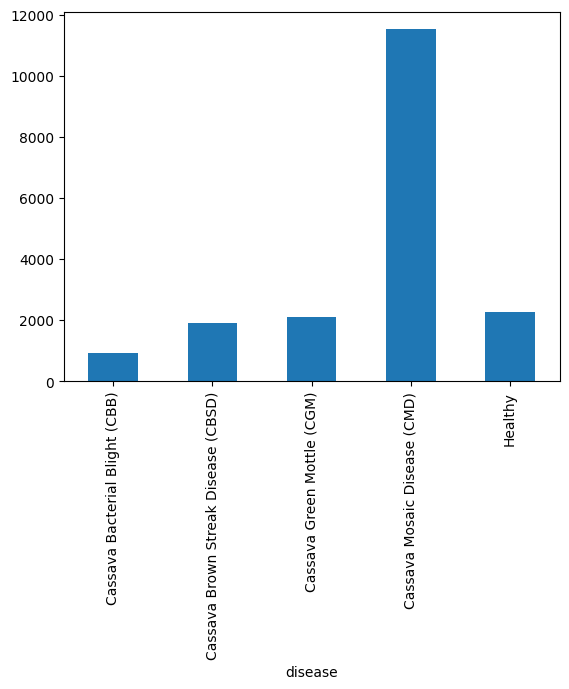

In [7]:
df_train.groupby(['disease']).size().plot(kind='bar')


In [8]:
import matplotlib.pyplot as plt
from PIL import Image


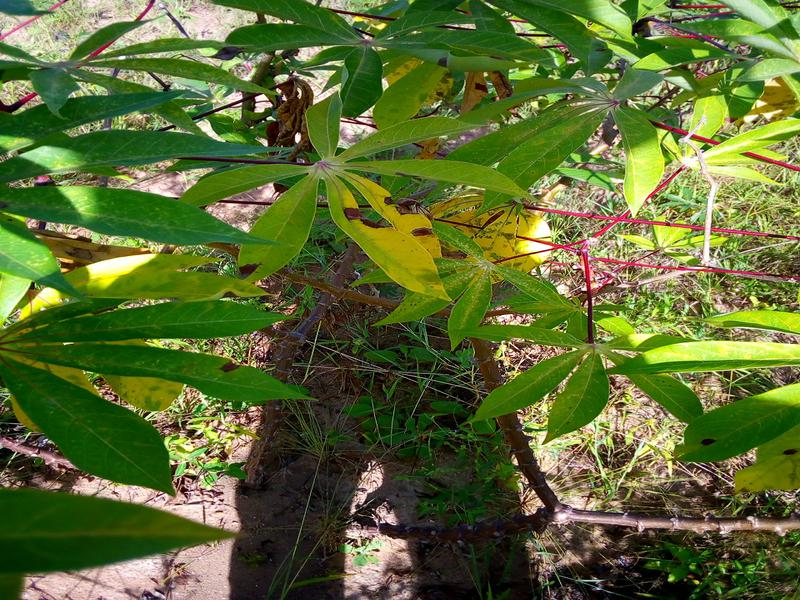

In [9]:
img = Image.open(df_train.path[0])
img


In [10]:
img.size


(800, 600)

In [11]:
from tqdm.notebook import tqdm #to monitor progress
np.random.seed(42) #to get reproducible results


In [12]:
df_samp = pd.DataFrame()

df_samp = df_samp.append(df_train.sample(500), ignore_index=True)

df_samp.groupby(by='disease').count()


AttributeError: 'DataFrame' object has no attribute 'append'

In [13]:
from sklearn.utils import shuffle

df_samp = shuffle(df_samp).reset_index(drop=True) #shuffling the dataframe


In [14]:
from sklearn.model_selection import train_test_split

X = df_samp.drop(columns=['label'])
y = df_samp.label

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, stratify=y)

print(X_train.shape)
print(len(y_train))
print(X_valid.shape)
print(len(y_valid))


KeyError: "['label'] not found in axis"

In [15]:
compressed_size = (200,150)


In [16]:
train_array = np.array([np.asarray(Image.open(path).resize(compressed_size, Image.ANTIALIAS)) for path in tqdm(X_train.path)])
valid_array = np.array([np.asarray(Image.open(path).resize(compressed_size, Image.ANTIALIAS)) for path in tqdm(X_valid.path)])

print(train_array.shape)
print(valid_array.shape)


NameError: name 'X_train' is not defined

In [17]:
plt.figure(figsize=(20,12))

for i, img in tqdm(enumerate(train_array[:5])):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img)
    plt.title(X_train.disease.iloc[i])
    plt.xlabel(X_train.image_id.iloc[i])

plt.show()


NameError: name 'train_array' is not defined

<Figure size 2000x1200 with 0 Axes>

In [18]:
plt.figure(figsize=(20,12))

for i, img in tqdm(enumerate(valid_array[:5])):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img)
    plt.title(X_valid.disease.iloc[i])
    plt.xlabel(X_valid.image_id.iloc[i])

plt.show()


NameError: name 'valid_array' is not defined

<Figure size 2000x1200 with 0 Axes>

In [19]:
print(f'Length of the training array is {len(train_array)}')
print(f'Shape of the training array is {train_array.shape}')
print(f'Shape of each training image array is {train_array[0].shape}')


NameError: name 'train_array' is not defined

In [20]:
train_array.resize(len(train_array), train_array.shape[1]*train_array.shape[2]*train_array.shape[3])

print(f'New length of the training array is {len(train_array)}')
print(f'New shape of the training array is {train_array.shape}')
print(f'New shape of each training image array is {train_array[0].shape}')


NameError: name 'train_array' is not defined

In [21]:
valid_array.resize(len(valid_array), valid_array.shape[1]*valid_array.shape[2]*valid_array.shape[3])

print(f'New length of the validation array is {len(valid_array)}')
print(f'New shape of the validation array is {valid_array.shape}')
print(f'New shape of each validation image array is {valid_array[0].shape}')


NameError: name 'valid_array' is not defined

In [22]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced', verbose=5, n_jobs=-1)


In [23]:
lr.fit(train_array, y_train)


NameError: name 'train_array' is not defined

In [24]:
preds = lr.predict(valid_array)


NameError: name 'valid_array' is not defined

In [25]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score


In [26]:
import seaborn as sns

label = sorted(y_valid.unique())
sns.heatmap(confusion_matrix(y_valid, preds), annot=True, square=True, fmt='g', 
            xticklabels=label, yticklabels=label, cbar=False)

plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


NameError: name 'y_valid' is not defined

In [27]:
print(classification_report(y_valid, preds))


NameError: name 'y_valid' is not defined

In [28]:
test_path = glob.glob(r'/kaggle/input/cassava-leaf-disease-classification/test_images/*.jpg')
test_path.sort()
print(len(test_path))
test_path


2676


['/kaggle/input/cassava-leaf-disease-classification/test_images/1234294272.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234332763.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234375577.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234555380.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234571117.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/123464878.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234924764.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1234931385.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1235142158.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/12351712.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1235188286.jpg',
 '/kaggle/input/cassava-leaf-disease-classification/test_images/1236036550.jpg',
 '/kaggle/input/cassava-leaf-di

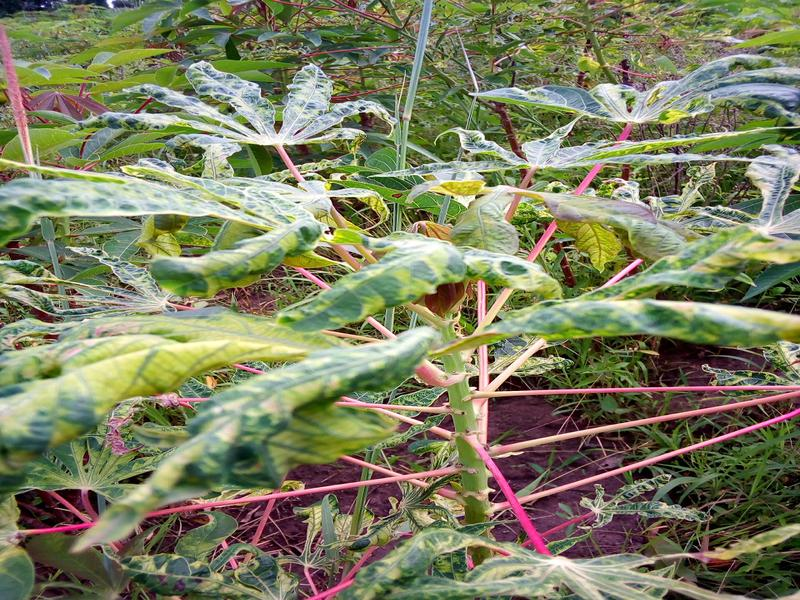

In [29]:
Image.open(test_path[0])


In [30]:
test_array = np.array([np.asarray(Image.open(path).resize(compressed_size, Image.ANTIALIAS)) for path in tqdm(test_path)])
test_array.resize(len(test_array), test_array.shape[1]*test_array.shape[2]*test_array.shape[3])


  0%|          | 0/2676 [00:00<?, ?it/s]

AttributeError: module 'PIL.Image' has no attribute 'ANTIALIAS'

In [31]:
submission = lr.predict(test_array)
submission


NameError: name 'test_array' is not defined

In [32]:
submission_df = pd.DataFrame({'image_id':[path.split('/')[-1] for path in test_path], 
                              'label':submission})
submission_df


NameError: name 'submission' is not defined

In [33]:
submission_df.to_csv('/kaggle/working/submission.csv', index=False)


NameError: name 'submission_df' is not defined